# Multi-level analysis of a Sentinel-2 scene (Zarr pyramid)

This notebook analyses the same sea area at several resolutions, from a Sentinel-2
scene processed with GRS and stored as a Zarr pyramid:

* tile 31TFJ, 23 May 2025: the Rhône delta and the Gulf of Lion;
* groups `0` to `4` of the store are the same scene at 20, 40, 80, 160 and 320 m;
* the variable `Rrs` holds the remote-sensing reflectance (sr⁻¹) at 11 wavelengths
  over water (NaN over land), and `mask` flags clouds and other invalid pixels.

Steps:

1. look at the pyramid and choose an area;
2. run {func}`~shades2shapes.diagnose_pyramid` on every level;
3. compare the metrics across levels;
4. keep the eddies found at several levels (*eddy tracks*);
5. export georeferenced maps.

It needs the `geo` extra (`pip install shades2shapes[geo]`: xarray, rioxarray, zarr).
The scene is not distributed with the package: set `ZARR` below, or the environment
variable `S2_ZARR`, to your own GRS product.

In [1]:
import os
import sys
from pathlib import Path

try:
    import shades2shapes as s2s
except ImportError:  # not installed: use the source tree of the repository
    src = next(p / "src" for p in [Path.cwd(), *Path.cwd().parents]
               if (p / "src" / "shades2shapes").is_dir())
    sys.path.insert(0, str(src))
    import shades2shapes as s2s

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from shades2shapes.multiscale import open_pyramid, pyramid_levels

%matplotlib inline
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
print("shades2shapes", s2s.__version__)

shades2shapes 0.1.0


In [2]:
ZARR = Path(os.environ.get("S2_ZARR",
    "/data/satellite/Sentinel-2/test/"
    "S2A_MSIL2AGRS_20250523T103701_N0511_R008_T31TFJ_20250523T131805_V3.0.1dev/"
    "S2A_MSIL2AGRS_20250523T103701_N0511_R008_T31TFJ_20250523T131805_V3.0.1dev.zarr"))
if not ZARR.exists():
    raise FileNotFoundError(f"{ZARR} not found: set ZARR or the S2_ZARR environment variable")
WL = "665"          # red band: sediment plumes
ZARR.name

'S2A_MSIL2AGRS_20250523T103701_N0511_R008_T31TFJ_20250523T131805_V3.0.1dev.zarr'

## 1. The pyramid

{func}`~shades2shapes.multiscale.pyramid_levels` reads the levels from the
`multiscales` attribute of the store, and
{func}`~shades2shapes.multiscale.open_pyramid` opens them lazily (nothing is loaded
yet).

In [3]:
levels = pyramid_levels(ZARR)
pyr = open_pyramid(ZARR)
pd.DataFrame({name: {"pixel (m)": float(ds.x[1] - ds.x[0]),
                     "size (px)": f"{ds.sizes['x']} x {ds.sizes['y']}"}
              for name, ds in pyr.items()}).T

,pixel (m),size (px)
0,20.0,5490 x 5490
1,40.0,2745 x 2745
2,80.0,1373 x 1373
3,160.0,687 x 687
4,320.0,344 x 344


In [4]:
ds = pyr["0"]
print(ds.Rrs.dims, "wavelengths:", ds.wl.values)
print("CRS variable:", ds.Rrs.attrs.get("grid_mapping"))
print(ds.mask.attrs["description"])

('wl', 'y', 'x') wavelengths: [ 443  490  560  665  705  740  783  842  865 1610 2190]
CRS variable: spatial_ref
good pixels for mask == 0, bad pixels when mask == 1


An overview at 160 m (level 3). Land is NaN; the mask also flags clouds. The analysed
area must be mostly valid water, because no-data pixels are filled from their
neighbours: here, a strip of open sea along the southern edge of the tile, off the
mouths of the Grand Rhône and the Petit Rhône (box in red, UTM 31N coordinates).

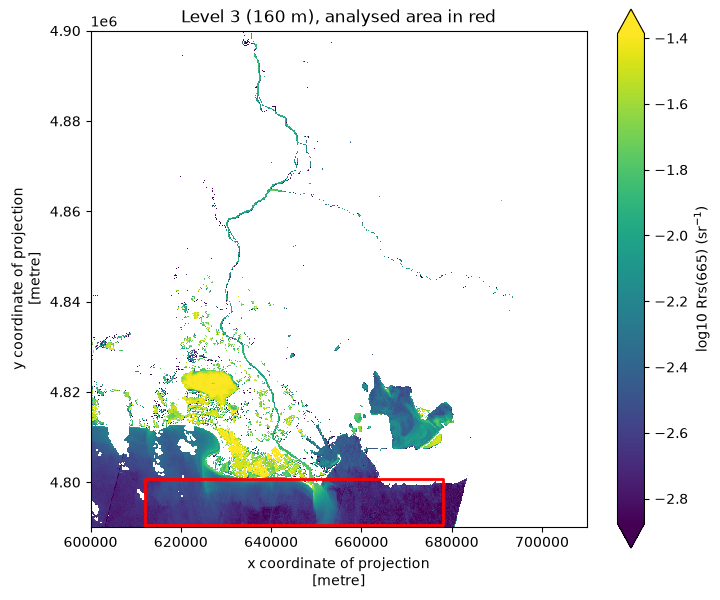

In [5]:
BBOX = (612000, 4790600, 678000, 4800600)     # xmin, ymin, xmax, ymax (m, EPSG:32631)

ov = pyr["3"]
r = np.log10(ov.Rrs.sel(wl=int(WL)).where(ov.mask == 0).clip(min=1e-4))
fig, ax = plt.subplots(figsize=(8, 7))
r.plot.imshow(ax=ax, cmap="viridis", robust=True,
              cbar_kwargs={"label": f"log10 Rrs({WL}) (sr$^{{-1}}$)"})
x0, y0, x1, y1 = BBOX
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r-", lw=2)
ax.set_aspect("equal")
ax.set_title("Level 3 (160 m), analysed area in red");

## 2. Diagnose every level

The options are those of {func}`~shades2shapes.diagnose`, plus:

* `variable`, `channel`: the band to analyse (`Rrs` at 665 nm);
* `bbox`: the same area is cut from every level;
* `mask`: invalid pixels (clouds), filled from their neighbours with NaN pixels;
* `transform="log10"`: reflectances span orders of magnitude between the plume and the
  open sea; without it, the bright plume saturates the normalisation;
* `min_size`: levels smaller than this (px) are skipped; eddies need room.

The pixel size of each level comes from its coordinates (`unit="km"`).

In [6]:
%%time
p = s2s.diagnose_pyramid(ZARR, variable="Rrs", channel=WL, mask="mask",
                         transform="log10", bbox=BBOX, min_size=48, unit="km")
p.levels

CPU times: user 27.8 s, sys: 4.51 s, total: 32.3 s
Wall time: 28.7 s


,pixel_size,shape,nodata_fraction,status
level,,,,
0,0.02,3300x500,0.027,ok
1,0.04,1650x251,0.028,ok
2,0.08,825x125,0.027,ok
3,0.16,413x63,0.030,ok
4,NaN,207x31,NaN,skipped: smaller than 48 px


Level 4 (320 m) is only 31 px high in this box and is skipped. About 3 % of the
pixels (clouds) were filled.

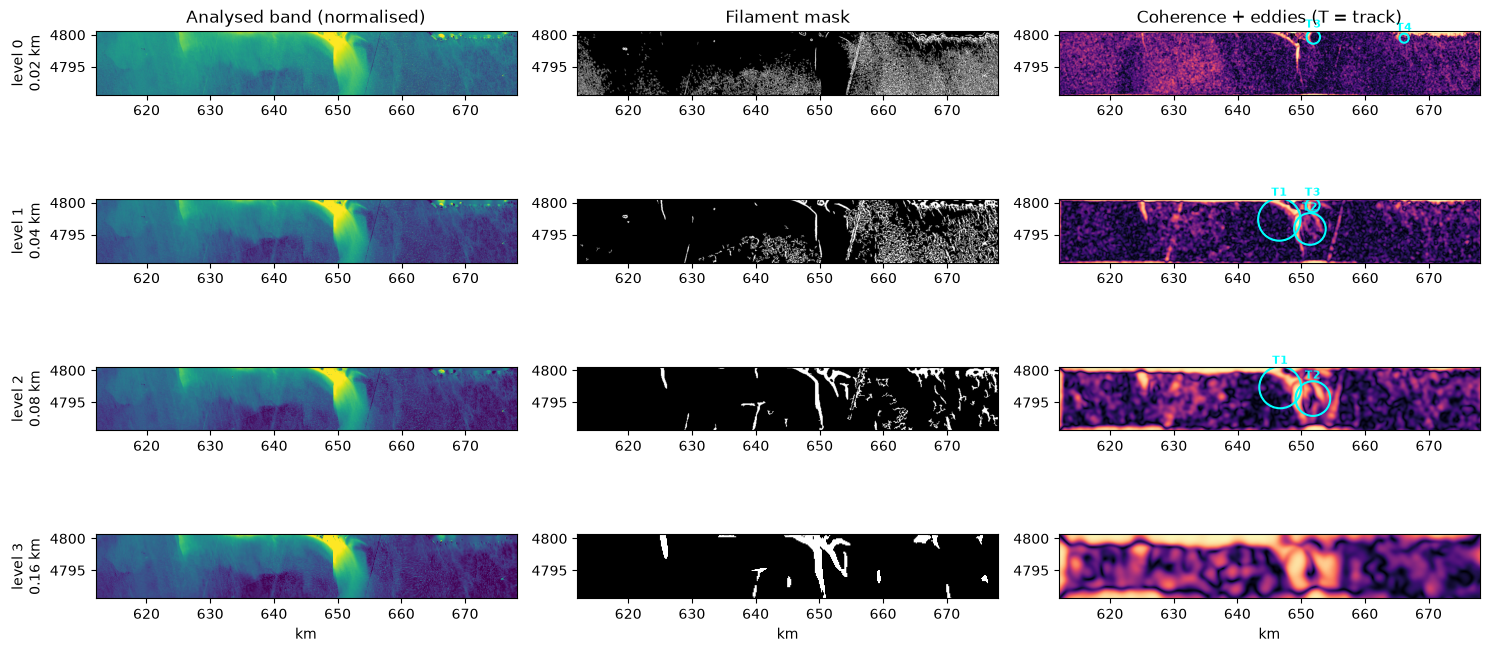

In [7]:
fig = p.plot()

Each row is one level, on the same map coordinates (km). Rows: the analysed band
(log10 Rrs(665), normalised), the filament mask and the orientation coherence with the
detected eddies, labelled by track (see section 4).

## 3. Metrics across levels

Most metrics depend on the pixel size. Finer levels resolve smaller filaments, but
also more noise: over clear water, the 20 m red band is mostly noise, which inflates
the filament fraction and the fractal dimension. Coarser levels keep only the main
fronts (plume edges), which are longer and more coherent.

In [8]:
p.metrics_table(s2s.multiscale.PYRAMID_METRICS)

,pixel_size,filament_fraction,skeleton_density_phys,branch_length_mean_phys,junction_endpoint_ratio,coherence_filaments,orientation_order,glcm_correlation_decay,spectral_slope,fractal_dimension,n_eddies
level,,,,,,,,,,,
0,0.02,0.190,5.027,0.101,0.875,0.234,0.623,0.968,-1.875,1.803,2.0
1,0.04,0.132,1.473,0.233,0.745,0.233,0.253,0.963,-2.375,1.692,3.0
2,0.08,0.074,0.290,0.712,0.579,0.407,0.248,0.954,-2.652,1.423,2.0
3,0.16,0.061,0.086,1.949,0.353,0.612,0.204,0.927,-2.996,1.399,0.0


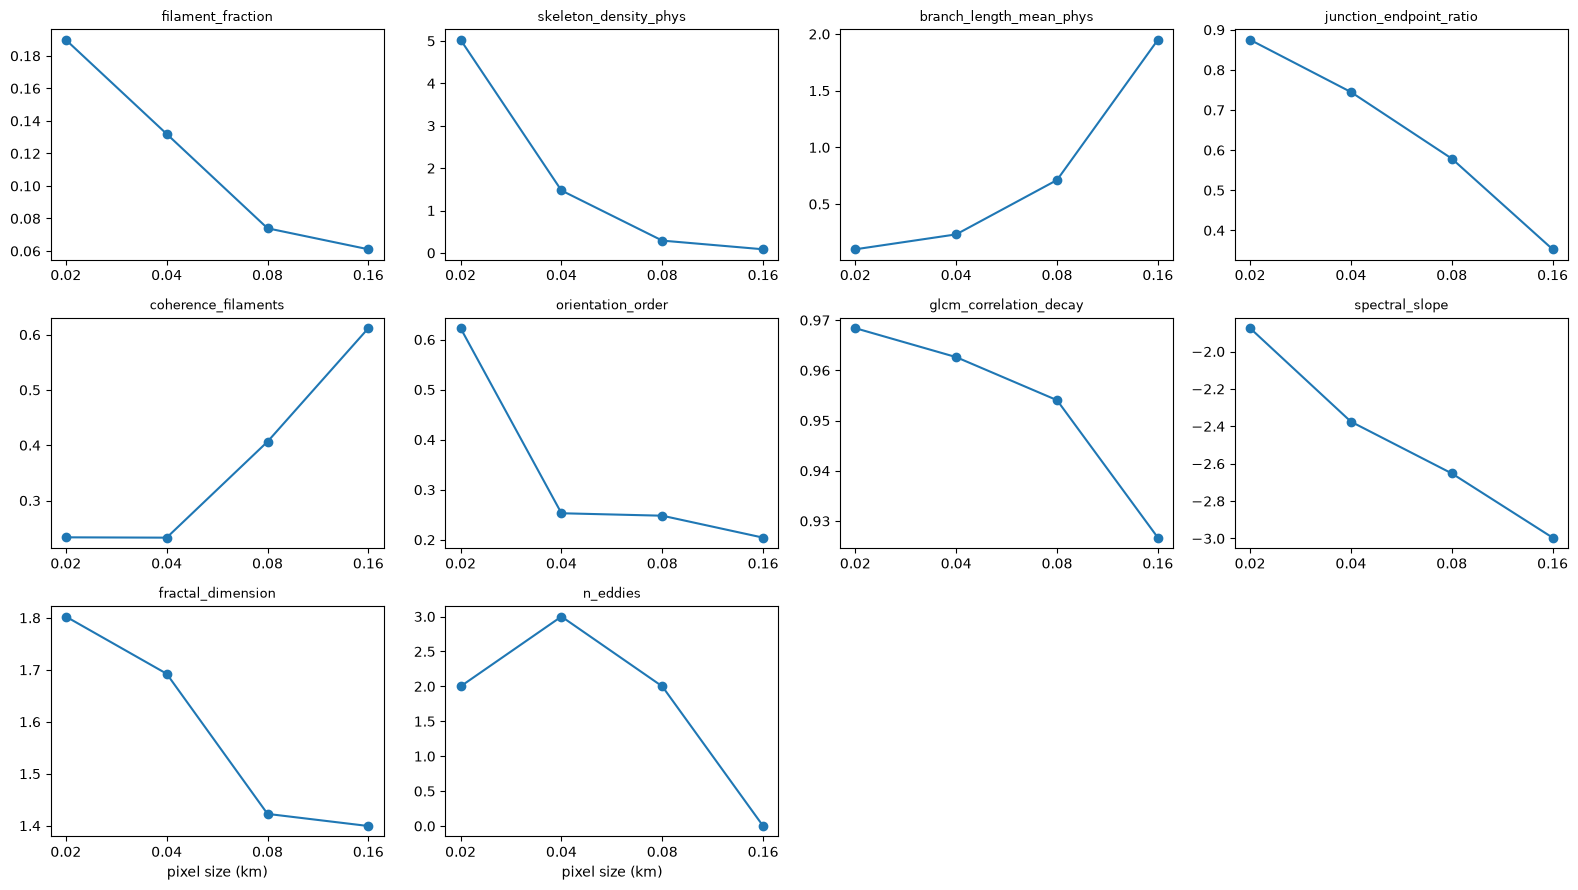

In [9]:
fig = p.plot_metrics()

## 4. Eddy tracks

An eddy detected at several levels, at the same place (centres closer than half the
larger radius) and with a similar radius (ratio < 2), is a robust structure. Detections
seen at a single level are more likely noise or a curved front.

In [10]:
p.eddy_tracks

,track,n_levels,levels,x_map,y_map,radius_map,radius_px_finest,max_significance,mean_alignment,lon,lat
0,1,2,"1,2",646610.0,4.797e+06,3300.0,165.0,2.640,0.637,4.808,43.315
1,2,2,"1,2",651570.0,4.796e+06,2600.0,130.0,2.030,0.565,4.869,43.299
2,3,2,"0,1",651825.0,4.800e+06,1070.0,53.5,1.953,0.696,4.873,43.334
3,4,1,0,666110.0,4.799e+06,720.0,36.0,2.029,0.605,5.049,43.330


In [11]:
p.eddies[["track", "level", "x", "y", "radius", "alignment", "significance",
          "lon", "lat"]]

,track,level,x,y,radius,alignment,significance,lon,lat
0,1,1,863.0,81.0,83.0,0.573,2.640,4.807,43.315
1,1,2,433.0,40.0,41.0,0.701,1.994,4.809,43.315
2,2,1,983.0,118.0,62.0,0.579,2.030,4.866,43.301
3,2,2,497.0,62.0,34.0,0.550,1.559,4.871,43.298
4,3,0,1993.0,46.0,53.0,0.717,1.953,4.873,43.335
5,3,1,994.0,25.0,27.0,0.675,1.603,4.872,43.334
6,4,0,2705.0,55.0,36.0,0.605,2.029,5.049,43.330


In [12]:
robust = p.eddy_tracks[p.eddy_tracks["n_levels"] >= 2]
for _, t in robust.iterrows():
    print(f"track {t['track']}: levels {t['levels']}, radius {t['radius_map'] / 1000:.1f} km,"
          f" at {t['lon']:.3f} E, {t['lat']:.3f} N")

track 1: levels 1,2, radius 3.3 km, at 4.808 E, 43.315 N
track 2: levels 1,2, radius 2.6 km, at 4.869 E, 43.299 N
track 3: levels 0,1, radius 1.1 km, at 4.873 E, 43.334 N


Track 1, about 3.3 km in radius, follows the front of the Grand Rhône plume, where it
bends westward; it is found at 40 and 80 m.

The full diagnosis of one level is a regular {class}`~shades2shapes.Diagnosis`:

In [13]:
d = p.diagnoses["1"]
print(d.summary())

shades2shapes diagnosis: S2A_MSIL2AGRS_20250523T103701_N0511_R008_T31TFJ_20250523T131805_V3.0.1dev.zarr[1]
  image 1650x251 px, channel 665
  georeferenced: EPSG:32631, pixel 40 x 40 metre
Filaments
  filament fraction       0.132
  skeleton density        58.9 px / 1000 px^2
Network
  junctions / endpoints   1813 / 2434  (ratio 0.74)
  junctions per 100 px    7.43
  branches                1313  (mean 5.8, median 4.0 px)
  closed mesh cells       438  (median area 26 px^2)
Orientation
  coherence (all / fil.)  0.224 / 0.233
  orientation order R     0.253  (dominant 104 deg)
Eddies
  #1: centre (863, 81) px, radius 83 px, alignment 0.57, significance 2.64
      at lon 4.80709, lat 43.31481
  #2: centre (983, 118) px, radius 62 px, alignment 0.58, significance 2.03
      at lon 4.86584, lat 43.30054
  #3: centre (994, 25) px, radius 27 px, alignment 0.68, significance 1.60
      at lon 4.87229, lat 43.33393
Texture
  GLCM contrast d1/d5     31.01 / 39.12
  GLCM correlation d1/d5  0.879

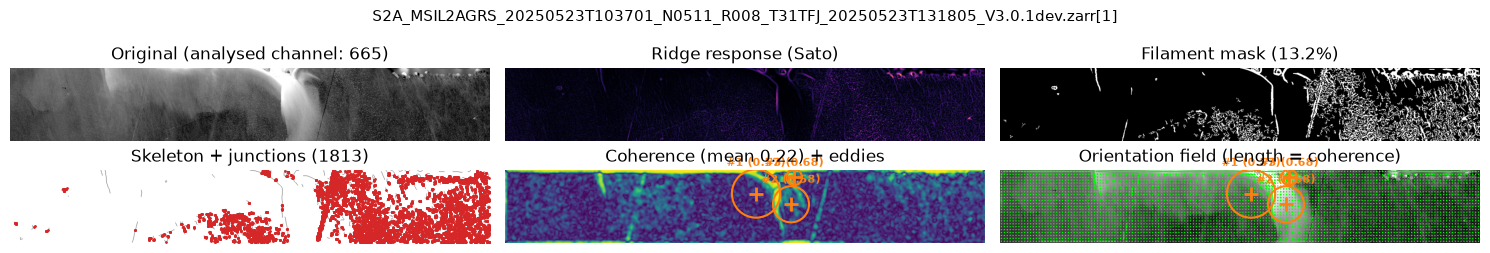

In [14]:
fig = d.plot()

## 5. Export

{meth}`~shades2shapes.PyramidDiagnosis.save` writes the tables (levels, metrics, eddy
tracks), a JSON file and, optionally, the figures and, with `maps=True`, the maps of
each level as NetCDF (large: about 60 MB for level 0 here). Here, figures are saved
from the returned objects: with `plots=True`, `save` switches matplotlib to a
non-interactive backend, which stops inline plots.

In [15]:
out = p.save("out_pyramid", plots=False)
p.plot().savefig(out / "pyramid.png", dpi=90)
p.plot_metrics().savefig(out / "metrics_by_level.png", dpi=100)
plt.close("all")
sorted(f.name for f in out.iterdir())

['eddies.csv',
 'eddy_tracks.csv',
 'level1_filament_mask.tif',
 'levels.csv',
 'metrics_by_level.csv',
 'metrics_by_level.png',
 'pyramid.json',
 'pyramid.png',
 'summary.txt']

The maps of a level are georeferenced, so they can be opened in a GIS or combined
with other data, e.g. as GeoTIFF:

In [16]:
maps = d.to_xarray()
print(maps.rio.crs, dict(maps.sizes))
maps.mask.rio.to_raster(out / "level1_filament_mask.tif")
maps

EPSG:32631 {'y': 251, 'x': 1650}


<xarray.Dataset> Size: 15MB
Dimensions:      (y: 251, x: 1650)
Coordinates:
  * y            (y) float64 2kB 4.801e+06 4.801e+06 ... 4.791e+06 4.791e+06
  * x            (x) float64 13kB 6.12e+05 6.121e+05 ... 6.779e+05 6.78e+05
    spatial_ref  int64 8B 0
Data variables:
    band         (y, x) float64 3MB 0.316 0.3728 0.3601 ... 0.2291 0.3333
    ridges       (y, x) float64 3MB 0.008423 0.005061 ... 0.01055 0.02989
    mask         (y, x) uint8 414kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 0 0 0 1
    skeleton     (y, x) uint8 414kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 1 0 0 0 1
    junctions    (y, x) uint8 414kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    coherence    (y, x) float64 3MB 0.133 0.1845 0.2703 ... 0.3219 0.3533 0.3797
    orientation  (y, x) float64 3MB 145.8 161.8 169.8 ... 85.22 84.18 83.42
Attributes: (12/59)
    source:                     S2A_MSIL2AGRS_20250523T103701_N0511_R008_T31T...
    channel:                    665
    software:                   shades2shapes
    filament_fraction:          0.13197150790776288
    skeleton_length_px:         24399
    skeleton_density:           58.913437160449114
    ...                         ...
    branch_length_mean_phys:    0.23284082254379285
    branch_length_median_phys:  0.16
    cell_area_median_phys:      0.041600000000000005
    skeleton_density_phys:      1.4728359290112278
    eddy_dominant_radius_phys:  3.3200000000000003
    eddies:                     [{"x": 863.0, "y": 81.0, "radius": 83.0, "ali...